# Autoencoder + PCA preprocessing for Quantum ML

This notebook loads the `classical_qi_predictions_all_splits` dataset, applies PCA and an autoencoder to reduce dimensionality, and saves the transformed embeddings for downstream Quantum ML experiments.

## Dataset

The notebook expects the dataset at `outputs/classical_qi_predictions_all_splits.csv` relative to this notebook's folder.

In [19]:
# Imports and environment checks
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import torch
from torch import nn

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('sklearn available')
print('torch', torch.__version__)

pandas 2.3.3
numpy 1.26.4
sklearn available
torch 2.8.0


In [27]:
# Paths and loading
data_path = Path('/Users/fagunawan/Documents/quantum_hack/code/4BE/QCentroid - ETH Hackathon 2026/aggregated_source_data.csv')
assert data_path.exists(), f'Data not found: {data_path}'
df = pd.read_csv(data_path)
print('Loaded', data_path)
display(df)

Loaded /Users/fagunawan/Documents/quantum_hack/code/4BE/QCentroid - ETH Hackathon 2026/aggregated_source_data.csv


,family,split,scenario,dataset_name,src_ip,flow_count,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,...,dst_port_concentration,top_dst_ip,top_protocol,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share,is_malicious_source
0,family_a,test,attack,attack_test_01,59.166.0.7,9360,10,2934,2,2822.727850,...,0.211325,149.171.126.0,TCP,0.772650,0.227350,0.0,0.618483,0.064530,0.052350,0
1,family_a,test,attack,attack_test_01,59.166.0.8,9390,10,2878,2,2807.146043,...,0.220980,149.171.126.1,TCP,0.781470,0.218530,0.0,0.618637,0.063685,0.051757,0
2,family_a,test,attack,attack_test_01,59.166.0.0,9797,10,2919,2,2793.548094,...,0.217618,149.171.126.0,TCP,0.770644,0.229356,0.0,0.621823,0.060937,0.054098,0
3,family_a,test,attack,attack_test_01,59.166.0.4,9782,10,3046,2,2857.151556,...,0.208444,149.171.126.4,TCP,0.773359,0.226641,0.0,0.615007,0.064200,0.054386,0
4,family_a,test,attack,attack_test_01,59.166.0.1,9982,10,2962,2,2734.413435,...,0.219495,149.171.126.0,TCP,0.778000,0.222000,0.0,0.621419,0.059507,0.054498,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2583,family_b,validation,normal,normal_validation_02,149.171.126.13,2,1,1,1,1.615687,...,1.000000,175.45.176.0,UDP,0.000000,1.000000,0.0,1.000000,0.000000,1.000000,0
2584,family_b,validation,normal,normal_validation_02,149.171.126.6,10,5,10,2,1830.956153,...,0.100000,59.166.0.8,TCP,0.900000,0.100000,0.0,0.200000,0.000000,0.700000,0
2585,family_b,validation,normal,normal_validation_02,149.171.126.17,2,2,1,1,1000.000000,...,1.000000,175.45.176.0,UDP,0.000000,1.000000,0.0,1.000000,0.000000,1.000000,0
2586,family_b,validation,normal,normal_validation_02,192.168.241.243,2,1,1,1,0.079552,...,1.000000,192.168.241.243,ICMP,0.000000,0.000000,1.0,0.000000,0.000000,1.000000,0


In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Multicollinearity test using VIF (Variance Inflation Factor)
print("Calculating VIF to detect multicollinearity...")

numeric_df = df.select_dtypes(include=[np.number]).dropna() # VIF cannot handle NaNs
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns

# Calculate VIF for each feature
# Warning: If the dataset is huge or has many columns, this can take a moment.
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

# Sort by VIF descending
vif_data = vif_data.sort_values(by="VIF", ascending=False)
display(vif_data.head(20)) # Display top 20 problematic features

# Generally, a VIF > 10 indicates high multicollinearity
correlated_cols_to_drop = vif_data[vif_data["VIF"] > 10]["feature"].tolist()

print(f"Total features with VIF > 10: {len(correlated_cols_to_drop)}")
if correlated_cols_to_drop:
    print("Consider dropping:", correlated_cols_to_drop)

Calculating VIF to detect multicollinearity...


,feature,VIF
0,flow_count,3120.229261
2,unique_dst_port,2907.104667
17,total_bytes_sum,650.233467
16,total_packets_sum,384.246129
14,inter_arrival_mean_mean,237.888250
15,inter_arrival_std_mean,208.493120
12,outbound_ratio_mean,118.495033
4,pps_mean,107.255290
20,tcp_share,99.130388
25,low_outbound_share,90.853581


Total features with VIF > 10: 22
Consider dropping: ['flow_count', 'unique_dst_port', 'total_bytes_sum', 'total_packets_sum', 'inter_arrival_mean_mean', 'inter_arrival_std_mean', 'outbound_ratio_mean', 'pps_mean', 'tcp_share', 'low_outbound_share', 'packet_size_avg_mean', 'unique_dst_ip', 'dst_concentration', 'pps_max', 'dst_port_concentration', 'small_packet_share', 'bps_mean', 'unique_protocols', 'packet_size_avg_std', 'udp_share', 'is_malicious_source', 'bps_max']


In [34]:
import statsmodels.api as sm

# OLS Regression Analysis for Multicollinearity
# If a target variable exists (e.g., 'scenario'), we can run OLS on it
print("\n" + "="*60)
print("OLS Regression Analysis for Multicollinearity Detection")
print("="*60)

# Prepare data for OLS
numeric_cols_list = numeric_df.columns.tolist()

# If 'scenario' exists, use it as target; otherwise use the first numeric column as a proxy
if 'scenario' in df.columns:
    # Encode scenario to numeric (0 for normal, 1 for attack)
    from sklearn.preprocessing import LabelEncoder
    le_temp = LabelEncoder()
    y_ols = le_temp.fit_transform(df.loc[numeric_df.index, 'scenario'])
    y_name = 'scenario'
else:
    # Use first numeric column as target (demonstration)
    y_ols = numeric_df.iloc[:, 0].values
    y_name = numeric_df.columns[0]

# Prepare X with constant for OLS
X_ols = sm.add_constant(numeric_df)

# Fit OLS model
ols_model = sm.OLS(y_ols, X_ols).fit()

# Display summary
print(f"\nOLS Regression Summary (Target: {y_name})")
print(ols_model.summary())

# Extract and display high p-value coefficients (potential collinearity indicators)
print("\n" + "-"*60)
print("Coefficients with high p-values (p > 0.05) - potential multicollinearity:")
print("-"*60)
high_p_coefs = ols_model.pvalues[ols_model.pvalues > 0.05]
if len(high_p_coefs) > 0:
    display(high_p_coefs.sort_values(ascending=False).head(15))
else:
    print("All features have significant p-values (p <= 0.05).")


OLS Regression Analysis for Multicollinearity Detection

OLS Regression Summary (Target: scenario)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     35.19
Date:                Sat, 09 May 2026   Prob (F-statistic):          1.21e-153
Time:                        22:40:00   Log-Likelihood:                -1279.2
No. Observations:                2588   AIC:                             2614.
Df Residuals:                    2560   BIC:                             2778.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------

unique_dst_port           0.995374
high_pps_share            0.975148
flow_count                0.948284
unique_protocols          0.934043
icmp_share                0.908057
total_bytes_sum           0.885521
outbound_ratio_min        0.852095
outbound_ratio_mean       0.845232
packet_size_avg_mean      0.828873
small_packet_share        0.827524
duration_mean             0.812040
packet_size_avg_std       0.803955
dst_port_concentration    0.753318
total_packets_sum         0.751833
inter_arrival_std_mean    0.737255
dtype: float64

In [ ]:
# Drop columns with missing values
df = df.drop(columns=['family', 'split', 'dataset_name', 'is_malicious_source', 'flow_count'], errors='ignore')

In [28]:
# Quick inspection and feature selection
print('shape:', df.shape)
print('columns:', list(df.columns))
# Select numeric columns only as features (drop identifiers / non-numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('numeric columns count:', len(numeric_cols))
X = df[numeric_cols].copy()
# Simple NaN handling: fill or drop depending on case (here fill with mean)
X = X.fillna(X.mean())
X.head()

shape: (2588, 34)
columns: ['family', 'split', 'scenario', 'dataset_name', 'src_ip', 'flow_count', 'unique_dst_ip', 'unique_dst_port', 'unique_protocols', 'pps_mean', 'pps_max', 'bps_mean', 'bps_max', 'duration_mean', 'duration_max', 'packet_size_avg_mean', 'packet_size_avg_std', 'outbound_ratio_mean', 'outbound_ratio_min', 'inter_arrival_mean_mean', 'inter_arrival_std_mean', 'total_packets_sum', 'total_bytes_sum', 'dst_concentration', 'dst_port_concentration', 'top_dst_ip', 'top_protocol', 'tcp_share', 'udp_share', 'icmp_share', 'small_packet_share', 'high_pps_share', 'low_outbound_share', 'is_malicious_source']
numeric columns count: 27


,flow_count,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,pps_max,bps_mean,bps_max,duration_mean,duration_max,...,total_bytes_sum,dst_concentration,dst_port_concentration,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share,is_malicious_source
0,9360,10,2934,2,2822.727850,15000.000000,525052.617439,3.117333e+06,0.491479,51.314,...,375459906,0.106410,0.211325,0.772650,0.227350,0.0,0.618483,0.064530,0.052350,0
1,9390,10,2878,2,2807.146043,14705.882353,525163.072909,4.572000e+06,0.466170,42.487,...,362940495,0.105857,0.220980,0.781470,0.218530,0.0,0.618637,0.063685,0.051757,0
2,9797,10,2919,2,2793.548094,15333.333333,517377.692440,3.117333e+06,0.470570,45.287,...,393494328,0.109523,0.217618,0.770644,0.229356,0.0,0.621823,0.060937,0.054098,0
3,9782,10,3046,2,2857.151556,13888.888889,535781.963064,4.572000e+06,0.464926,41.314,...,414947073,0.107544,0.208444,0.773359,0.226641,0.0,0.615007,0.064200,0.054386,0
4,9982,10,2962,2,2734.413435,15333.333333,511894.821941,3.117333e+06,0.522160,49.039,...,418298251,0.105891,0.219495,0.778000,0.222000,0.0,0.621419,0.059507,0.054498,0


In [29]:
# Autoencoder followed by PCA
# This approach uses a non-linear autoencoder to learn a compressed representation, 
# and then PCA is applied to the latent space for further linear dimensionality reduction.

# Define the Autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, encoding_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()  # To produce output in [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Normalize the data to be in the range [0, 1] for the Sigmoid output
scaler_01 = MinMaxScaler()
X_scaled_01 = scaler_01.fit_transform(X)
X_tensor = torch.tensor(X_scaled_01, dtype=torch.float32)

# Hyperparameters
input_dim = X.shape[1]
encoding_dim = 32  # Intermediate latent space dimension
final_latent_dim = 10
epochs = 1000
batch_size = 64
learning_rate = 1e-3

# Model, loss, and optimizer
autoencoder = Autoencoder(input_dim, encoding_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    for i in range(0, len(X_tensor), batch_size):
        batch = X_tensor[i:i+batch_size]
        # Forward pass
        outputs = autoencoder(batch)
        loss = criterion(outputs, batch)
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Get the latent space representation from the encoder
with torch.no_grad():
    latent_representation = autoencoder.encoder(X_tensor).numpy()

# Apply PCA on the latent space
pca_on_latent = PCA(n_components=final_latent_dim)
final_representation = pca_on_latent.fit_transform(latent_representation)

print("Shape of the final representation:", final_representation.shape)

# Save the final representation
df_final = pd.DataFrame(final_representation, columns=[f'latent_{i+1}' for i in range(final_latent_dim)])
output_path = base / 'outputs' / 'autoencoder_pca_representation.csv'
df_final.to_csv(output_path, index=False)
print(f"Saved final representation to {output_path}")

Epoch [1/1000], Loss: 0.0860
Epoch [2/1000], Loss: 0.0476
Epoch [3/1000], Loss: 0.0298
Epoch [4/1000], Loss: 0.0296
Epoch [5/1000], Loss: 0.0235
Epoch [6/1000], Loss: 0.0129
Epoch [7/1000], Loss: 0.0100
Epoch [8/1000], Loss: 0.0089
Epoch [9/1000], Loss: 0.0075
Epoch [10/1000], Loss: 0.0066
Epoch [11/1000], Loss: 0.0057
Epoch [12/1000], Loss: 0.0048
Epoch [13/1000], Loss: 0.0043
Epoch [14/1000], Loss: 0.0041
Epoch [15/1000], Loss: 0.0039
Epoch [16/1000], Loss: 0.0038
Epoch [17/1000], Loss: 0.0037
Epoch [18/1000], Loss: 0.0036
Epoch [19/1000], Loss: 0.0035
Epoch [20/1000], Loss: 0.0034
Epoch [21/1000], Loss: 0.0034
Epoch [22/1000], Loss: 0.0033
Epoch [23/1000], Loss: 0.0033
Epoch [24/1000], Loss: 0.0032
Epoch [25/1000], Loss: 0.0031
Epoch [26/1000], Loss: 0.0030
Epoch [27/1000], Loss: 0.0030
Epoch [28/1000], Loss: 0.0030
Epoch [29/1000], Loss: 0.0029
Epoch [30/1000], Loss: 0.0028
Epoch [31/1000], Loss: 0.0027
Epoch [32/1000], Loss: 0.0026
Epoch [33/1000], Loss: 0.0027
Epoch [34/1000], Lo

In [30]:
display(df_final)

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10
0,0.907316,1.077070,0.748626,-1.161445,0.339665,-0.057293,-0.081648,0.071043,-0.069613,0.182845
1,0.863079,0.896062,0.497623,-1.321937,0.422713,-0.294237,-0.103569,-0.064325,0.119047,0.048316
2,1.074986,0.990749,0.848083,-1.270000,0.362221,-0.145470,-0.075520,0.150982,-0.131086,0.157450
3,1.114732,1.078353,0.476561,-1.316182,0.371721,-0.514220,-0.023898,0.156580,-0.007226,0.017651
4,1.183359,1.219964,0.895290,-1.216610,0.312541,-0.183948,-0.090580,0.234373,-0.190880,0.140228
...,...,...,...,...,...,...,...,...,...,...
2583,-4.709352,2.480163,0.839134,0.440389,0.418545,0.800797,-1.091901,1.046981,-0.433156,0.033137
2584,-0.271244,1.479381,-2.447325,0.712938,0.917138,0.300844,-0.219642,-0.700128,0.376211,-0.031306
2585,-2.559536,-2.281034,-0.465113,-0.986746,-0.391653,0.315898,0.028656,1.443982,0.625068,-1.642653
2586,-2.513356,4.468220,-1.969353,0.459751,0.457732,0.191006,1.478232,0.527363,-0.551610,0.042780


Total PCA Explained Variance (10 components): 0.9590
If this is close to 1.0, the 10 components captured almost all the variance of the 32D latent space.



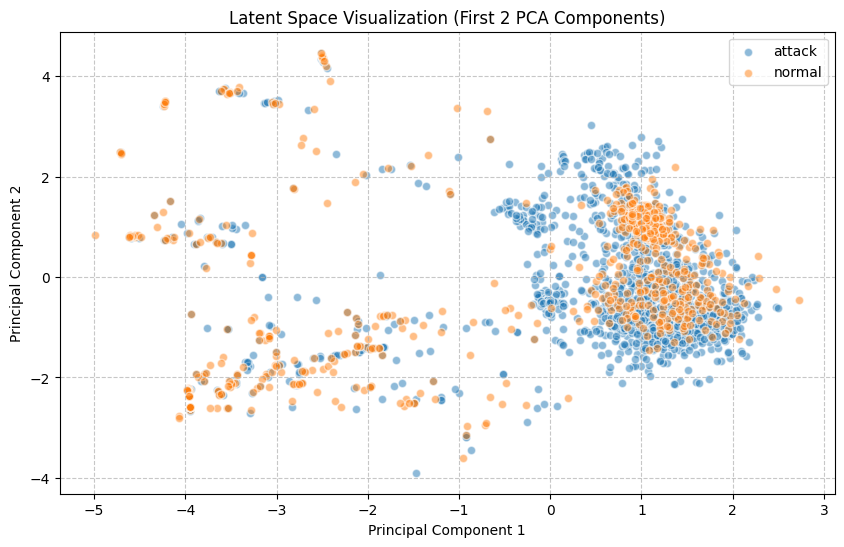

In [31]:
import matplotlib.pyplot as plt

# 1. Check PCA Explained Variance
explained_variance = sum(pca_on_latent.explained_variance_ratio_)
print(f"Total PCA Explained Variance ({final_latent_dim} components): {explained_variance:.4f}")
print("If this is close to 1.0, the 10 components captured almost all the variance of the 32D latent space.\n")

# 2. Visualize the top 2 components of the latent space
plt.figure(figsize=(10, 6))

if 'scenario' in df.columns:
    # Plot with clusters colored by the 'scenario' label (attack vs normal)
    labels = df['scenario'].unique()
    for label in labels:
        idx = df['scenario'] == label
        plt.scatter(
            final_representation[idx, 0], 
            final_representation[idx, 1], 
            label=label, 
            alpha=0.5, 
            edgecolors='w'
        )
    plt.legend()
    plt.title('Latent Space Visualization (First 2 PCA Components)')
else:
    plt.scatter(final_representation[:, 0], final_representation[:, 1], alpha=0.5)
    plt.title('Latent Space Visualization (First 2 PCA Components)')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Next steps
- Use `outputs/autoencoder_pca_representation.csv` as input features for Quantum ML pipelines.
- Tune `encoding_dim`, `final_latent_dim`, network size, and training epochs for best downstream performance.

## Requirements
Run the following to install required packages if not already available:
```
pip install pandas numpy scikit-learn torch torchvision
```